# Lecture 05 Practice - A Binary Evolutionary Algorithm

This notebook builds an evolutionary algorithm step by step with a binary
optimization problem. The objective is intentionally simple:

$$
\text{OneMax}(\mathbf{x}) = \sum_i x_i,
\qquad x_i\in\{0,1\}.
$$

The goal is to maximize the number of ones. The simplicity keeps attention on
population, selection, variation, survivor creation, and the behavior of the
algorithm over time.


## Setup and Visual Conventions

Blue cells contribute genetic material from the first displayed parent. Orange
cells contribute material from the second displayed parent. Red outlines mark
mutated loci. The same helpers are used throughout the practical so that visual
changes remain easy to interpret.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyBboxPatch

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.22

BLUE = "#4c78a8"
ORANGE = "#f58518"
RED = "#e45756"
NEUTRAL = "#edf1f4"
DARK = "#34495e"

def plot_chromosome(ax, bits, y=0, label="", highlights=(), segment_colors=None,
                    show_indices=True, box_height=0.72):
    bits = np.asarray(bits, dtype=int)
    if segment_colors is None:
        segment_colors = [BLUE if bit else NEUTRAL for bit in bits]
    for locus, (bit, color) in enumerate(zip(bits, segment_colors)):
        edge = RED if locus in set(highlights) else DARK
        linewidth = 3.0 if locus in set(highlights) else 1.35
        ax.add_patch(Rectangle((locus, y), 1, box_height, facecolor=color,
                               edgecolor=edge, lw=linewidth))
        ax.text(locus + 0.5, y + box_height / 2, str(bit), ha="center", va="center",
                fontsize=14, weight="bold", color="white" if color not in {NEUTRAL, "#ffffff"} else DARK)
        if show_indices:
            ax.text(locus + 0.5, y + box_height + 0.16, str(locus), ha="center", va="center",
                    fontsize=9, color="#555555")
    if label:
        ax.text(-0.25, y + box_height / 2, label, ha="right", va="center", fontsize=11)

def format_chromosome_axis(ax, length, rows=1):
    ax.set_xlim(-2.0, length + 0.45)
    ax.set_ylim(-0.4, rows * 1.25 + 0.55)
    ax.axis("off")

def onemax(individual):
    return int(np.sum(individual))

def evaluate_population(population):
    return np.asarray(population, dtype=int).sum(axis=1)

def population_diversity(population):
    p_one = np.asarray(population).mean(axis=0)
    return float(np.mean(4 * p_one * (1 - p_one)))

def plot_population(population, fitness=None, title="Population"):
    population = np.asarray(population, dtype=int)
    if fitness is None:
        fitness = evaluate_population(population)
    order = np.argsort(fitness)[::-1]
    sorted_population = population[order]
    sorted_fitness = np.asarray(fitness)[order]
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios": [3.7, 1]})
    image = axes[0].imshow(sorted_population, aspect="auto", cmap=plt.cm.Blues, vmin=0, vmax=1)
    axes[0].set(xlabel="locus", ylabel="individual (sorted)", title=title)
    axes[0].set_yticks(range(len(sorted_population)))
    axes[0].set_yticklabels([f"#{i}" for i in order])
    axes[1].barh(np.arange(len(sorted_fitness)), sorted_fitness, color=BLUE)
    axes[1].invert_yaxis()
    axes[1].set(xlabel="fitness", yticks=[], title="OneMax")
    axes[1].set_xlim(0, population.shape[1] + 1)
    plt.tight_layout()
    plt.show()
    return order


# Part 1 - Detailed Binary Evolutionary Algorithm

## 1. Representation

A fixed-length binary string is the genotype. Its loci are positions, its
alleles are 0 and 1, and each displayed box is one gene. For OneMax, the
phenotype can be read directly as the binary choices, so the genotype-to-
phenotype mapping is deliberately simple.


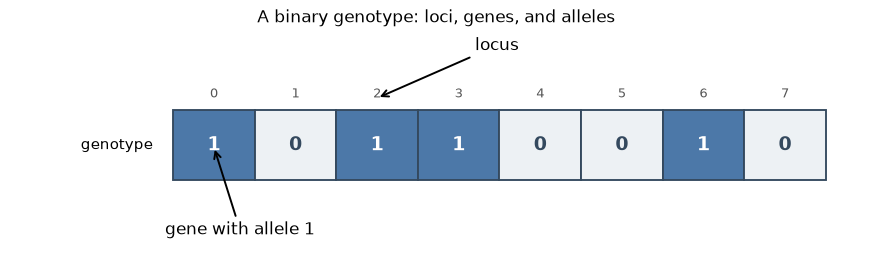

In [2]:
example = np.array([1, 0, 1, 1, 0, 0, 1, 0])
fig, ax = plt.subplots(figsize=(11, 2.8))
plot_chromosome(ax, example, y=0.3, label="genotype")
format_chromosome_axis(ax, len(example))
ax.annotate("locus", xy=(2.5, 1.14), xytext=(3.7, 1.63),
            arrowprops={"arrowstyle": "->", "lw": 1.4}, fontsize=12)
ax.annotate("gene with allele 1", xy=(0.5, 0.64), xytext=(-0.1, -0.25),
            arrowprops={"arrowstyle": "->", "lw": 1.4}, fontsize=12)
ax.set_title("A binary genotype: loci, genes, and alleles", pad=8)
plt.show()


## Exercise 1 - Represent and Evaluate Binary Individuals

Complete the fitness function. It must return the number of ones in an
individual. Then calculate the fitness of the three example genotypes.


In [3]:
def onemax_task(individual):
    
    return int(np.sum(individual))

examples = [
    np.array([1, 0, 1, 1, 0, 1, 0, 0]),
    np.array([0, 0, 0, 1, 0, 0, 0, 0]),
    np.array([1, 1, 1, 1, 1, 1, 1, 1]),
]
print([onemax_task(individual) for individual in examples])


[4, 1, 8]


## 2. Fitness and a Small Population

Fitness allows candidates to be ranked. The following population is visualized
as rows of genotypes and sorted by fitness. Best fitness, mean fitness, and
diversity summarize different aspects of the population.


best fitness: 8
mean fitness: 5.88
diversity: 0.859


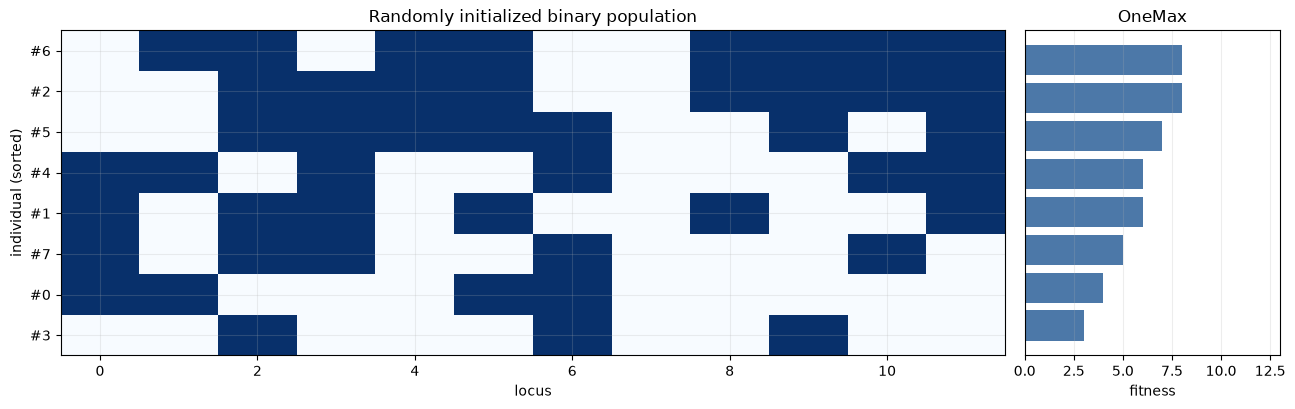

array([6, 2, 5, 4, 1, 7, 0, 3])

In [4]:
population_rng = np.random.default_rng(17)
small_population = population_rng.integers(0, 2, size=(8, 12))
small_fitness = evaluate_population(small_population)
print("best fitness:", small_fitness.max())
print("mean fitness:", round(small_fitness.mean(), 2))
print("diversity:", round(population_diversity(small_population), 3))
plot_population(small_population, small_fitness, title="Randomly initialized binary population")


The population is the basic unit of evolution. Selection compares population
members; mutation and recombination transform individual genotypes. Fitness is
not the algorithm itself: it is the evaluator that makes comparison possible.

The displayed normalized diversity is the mean of $4p(1-p)$ across loci, where
$p$ is the fraction of individuals with allele 1 at that locus. A value near 1
means that loci are strongly mixed between 0 and 1; a value near 0 means that
each locus has become fixed to one allele across the population.


## 3. Bit-Flip Mutation

In a binary genotype, each locus mutates independently with probability
$p_m$. A mutation flips 0 to 1 or 1 to 0. Mutation creates variation; its
visible impact depends strongly on the mutation rate.


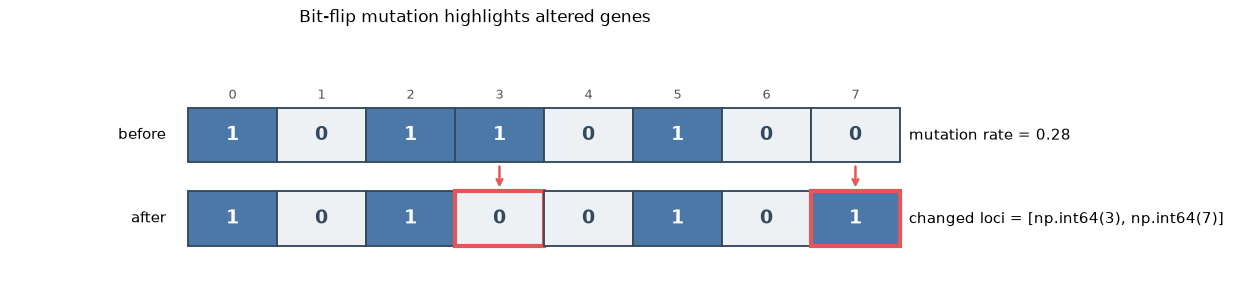

In [5]:
def bit_flip_mutation(individual, mutation_rate, rng):
    individual = np.asarray(individual, dtype=int)
    changed = rng.random(individual.size) < mutation_rate
    mutated = individual.copy()
    mutated[changed] = 1 - mutated[changed]
    return mutated, np.flatnonzero(changed)

def plot_mutation(before, after, changed, mutation_rate):
    fig, ax = plt.subplots(figsize=(12, 3.4))
    plot_chromosome(ax, before, y=1.35, label="before", show_indices=True)
    plot_chromosome(ax, after, y=0.25, label="after", highlights=changed, show_indices=False)
    for locus in changed:
        ax.annotate("", xy=(locus + 0.5, 0.98), xytext=(locus + 0.5, 1.33),
                    arrowprops={"arrowstyle": "->", "color": RED, "lw": 1.8})
    format_chromosome_axis(ax, len(before), rows=2)
    ax.text(len(before) + 0.1, 1.7, f"mutation rate = {mutation_rate}", va="center", fontsize=11)
    ax.text(len(before) + 0.1, 0.6, f"changed loci = {list(changed)}", va="center", fontsize=11)
    ax.set_title("Bit-flip mutation highlights altered genes", pad=8)
    plt.show()

mutation_example = np.array([1, 0, 1, 1, 0, 1, 0, 0])
mutation_rng = np.random.default_rng(4)
mutated_example, changed_example = bit_flip_mutation(mutation_example, 0.28, mutation_rng)
plot_mutation(mutation_example, mutated_example, changed_example, 0.28)


## Exercise 2 - Implement Bit-Flip Mutation

Complete the mutation function. The return value should contain the altered
individual and the indices that changed. Keep the input individual unchanged.


In [6]:
def bit_flip_mutation_task(individual, mutation_rate, rng):

    changed = rng.random(len(individual,dtype = int)) < mutation_rate
    mutated = individual.copy 
    mutated[changed]= 1-mutated[changed]

    return individual, changed


## 4. Mutation-Rate Experiment

Before running the cell, predict the visible outcome for rates 0, 0.15, 0.65,
and 1. The same random seed is used for each panel so that the rate is the
only changed factor.


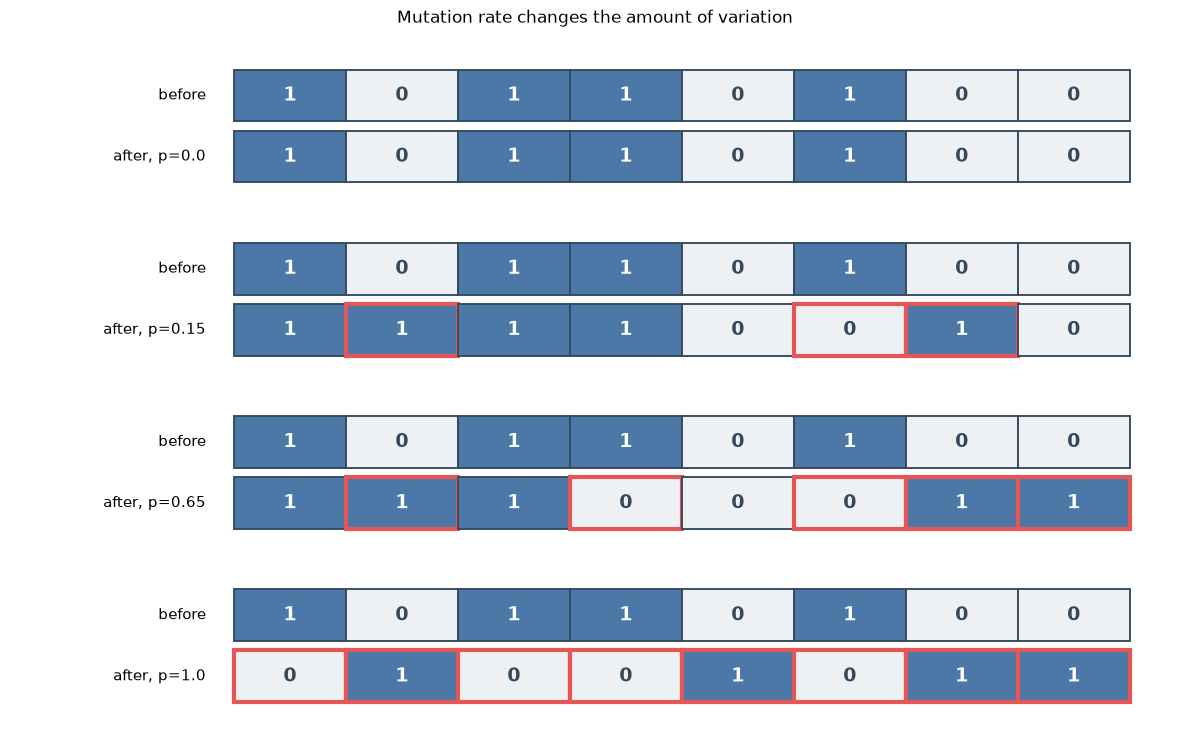

In [9]:
rates = [0.0, 0.15, 0.65, 1.0]
fig, axes = plt.subplots(len(rates), 1, figsize=(12, 7.4))
for ax, rate in zip(axes, rates):
    mutated, changed = reference_bit_flip_mutation(
        mutation_example, rate, np.random.default_rng(31)
    )
    plot_chromosome(ax, mutation_example, y=0.85, label="before", show_indices=False)
    plot_chromosome(ax, mutated, y=0.0, label=f"after, p={rate}", highlights=changed, show_indices=False)
    format_chromosome_axis(ax, len(mutation_example), rows=1)
fig.suptitle("Mutation rate changes the amount of variation", y=0.995)
plt.tight_layout()
plt.show()


A small rate makes local random changes. A large rate can alter many genes at
once and may destroy useful structures as readily as it creates novelty. The
effect is representation- and parameter-dependent; mutation cannot be labelled
as purely exploratory or purely exploitative in every setting.


## 5. One-Point Crossover

One-point crossover selects a cut between loci, then exchanges the tails of two
binary parents. It creates two offspring. The visualization below makes the
inherited segments explicit.


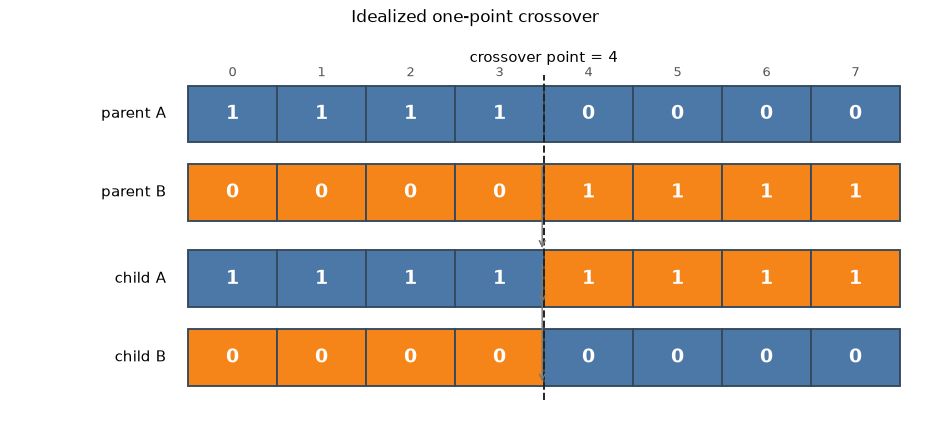

In [10]:
def one_point_crossover(parent_a, parent_b, rng, cut=None):
    parent_a = np.asarray(parent_a, dtype=int)
    parent_b = np.asarray(parent_b, dtype=int)
    if parent_a.shape != parent_b.shape or parent_a.ndim != 1:
        raise ValueError("Parents must be one-dimensional binary strings of equal length.")
    if len(parent_a) < 2:
        raise ValueError("One-point crossover requires at least two loci.")
    if cut is None:
        cut = int(rng.integers(1, len(parent_a)))
    child_a = np.concatenate([parent_a[:cut], parent_b[cut:]])
    child_b = np.concatenate([parent_b[:cut], parent_a[cut:]])
    return child_a, child_b, cut

def plot_crossover(parent_a, parent_b, child_a, child_b, cut, title):
    fig, ax = plt.subplots(figsize=(12, 5.0))
    colors_a = [BLUE] * len(parent_a)
    colors_b = [ORANGE] * len(parent_b)
    child_a_colors = [BLUE if i < cut else ORANGE for i in range(len(parent_a))]
    child_b_colors = [ORANGE if i < cut else BLUE for i in range(len(parent_a))]
    plot_chromosome(ax, parent_a, y=3.0, label="parent A", segment_colors=colors_a)
    plot_chromosome(ax, parent_b, y=2.0, label="parent B", segment_colors=colors_b, show_indices=False)
    plot_chromosome(ax, child_a, y=0.9, label="child A", segment_colors=child_a_colors, show_indices=False)
    plot_chromosome(ax, child_b, y=-0.1, label="child B", segment_colors=child_b_colors, show_indices=False)
    for y_start, y_end in [(2.72, 1.62), (1.72, 1.62), (1.48, 0.92), (1.48, -0.08)]:
        ax.annotate("", xy=(cut - 0.02, y_end), xytext=(cut - 0.02, y_start),
                    arrowprops={"arrowstyle": "->", "color": "#777777", "lw": 1.0})
    ax.vlines(cut, -0.28, 3.85, color="#222222", ls="--", lw=1.4)
    ax.text(cut, 4.02, f"crossover point = {cut}", ha="center", fontsize=11)
    format_chromosome_axis(ax, len(parent_a), rows=4)
    ax.set_ylim(-0.55, 4.35)
    ax.set_title(title, pad=10)
    plt.show()

parent_a = np.array([1, 1, 1, 1, 0, 0, 0, 0])
parent_b = np.array([0, 0, 0, 0, 1, 1, 1, 1])
child_a, child_b, cut = one_point_crossover(parent_a, parent_b, np.random.default_rng(1), cut=4)
plot_crossover(parent_a, parent_b, child_a, child_b, cut,
               "Idealized one-point crossover")


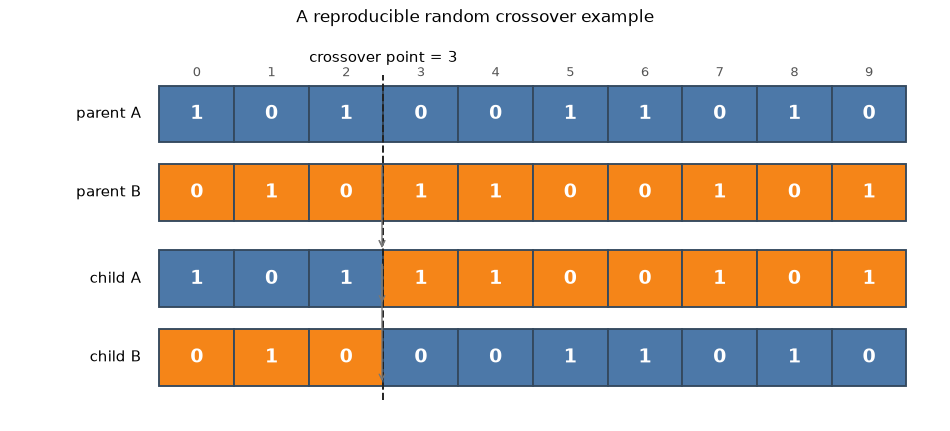

In [11]:
random_parent_a = np.array([1, 0, 1, 0, 0, 1, 1, 0, 1, 0])
random_parent_b = np.array([0, 1, 0, 1, 1, 0, 0, 1, 0, 1])
random_child_a, random_child_b, random_cut = one_point_crossover(
    random_parent_a, random_parent_b, np.random.default_rng(21)
)
plot_crossover(random_parent_a, random_parent_b, random_child_a, random_child_b,
               random_cut, "A reproducible random crossover example")


## Exercise 3 - Implement One-Point Crossover

Complete the function. The cut must be in the range 1 through length minus 1,
so both head and tail contribute to each child.


In [1]:
def one_point_crossover_task(parent_a, parent_b, rng):
    parent_a =np.asarray(parent_a,dtype=int)
    parent_b = np.asarray(parent_b,dtype=int)
    if parent_a.shape != parent_b.shape or parent_a.ndim != 1:
        raise ValueError("Parents must be one-dimensional binary strings of equal length.")
    if len(parent_a) < 2:
        raise ValueError("One-point crossover requires at least two loci.")
    if cut is None:
        cut = int(rng.integers(1, len(parent_a)))

    child_a = np.concatenate([parent_a[:cut], parent_b[cut:]])
    child_b = np.concatenate([parent_b[:cut], parent_a[cut:]])
    # TODO: create two children by exchanging tails.
    return child_a, child_b, cut


## 6. Basic Parent Selection

A small tournament is sufficient for this practical. It samples a few
population members and selects the fittest sampled member. Higher fitness gives
a better chance to become a parent, but the outcome remains stochastic because
the sampled group is random.


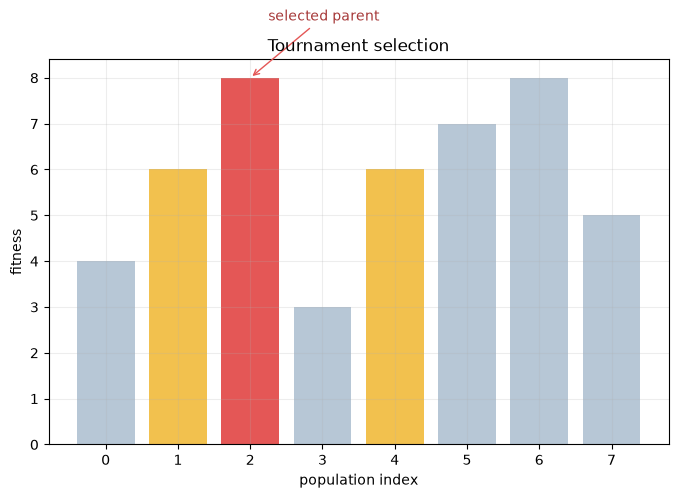

contenders: [2, 4, 1]
selected index: 2


In [15]:
def tournament_select(population, fitness, rng, tournament_size=3):
    contenders = rng.choice(len(population), size=tournament_size, replace=False)
    winner = contenders[np.argmax(fitness[contenders])]
    return population[winner].copy(), winner, contenders

selection_rng = np.random.default_rng(8)
selected_parent, selected_index, contenders = tournament_select(
    small_population, small_fitness, selection_rng, tournament_size=3
)
fig, ax = plt.subplots()
colors = ["#b7c7d6"] * len(small_fitness)
for index in contenders:
    colors[index] = "#f2c14e"
colors[selected_index] = RED
ax.bar(range(len(small_fitness)), small_fitness, color=colors)
ax.set(xlabel="population index", ylabel="fitness", title="Tournament selection")
ax.annotate("selected parent", xy=(selected_index, small_fitness[selected_index]),
            xytext=(selected_index + 0.25, small_fitness[selected_index] + 1.25),
            arrowprops={"arrowstyle": "->", "color": RED}, color="#a63838")
plt.show()
print("contenders:", contenders.tolist())
print("selected index:", selected_index)


## 7. One Complete Generation, Step by Step

The following cells make one generation visible rather than hiding it inside a
large function. A selected parent pair is recombined, children are mutated,
offspring are evaluated, and survivor creation forms the next population.


parent A: population #6, fitness=8
parent B: population #2, fitness=8


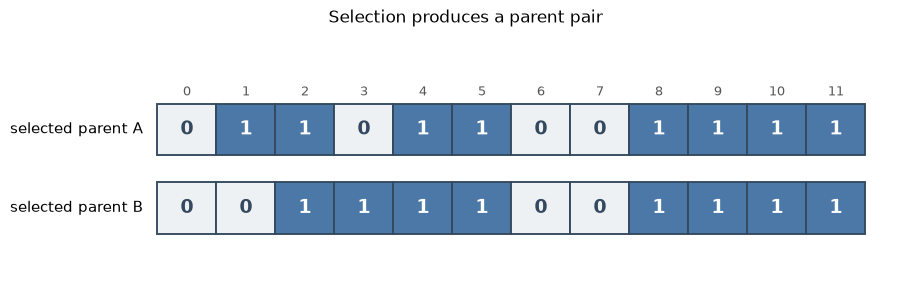

In [16]:
generation_rng = np.random.default_rng(44)
parent_a, index_a, contenders_a = tournament_select(
    small_population, small_fitness, generation_rng
)
parent_b, index_b, contenders_b = tournament_select(
    small_population, small_fitness, generation_rng
)
print(f"parent A: population #{index_a}, fitness={onemax(parent_a)}")
print(f"parent B: population #{index_b}, fitness={onemax(parent_b)}")

fig, ax = plt.subplots(figsize=(11, 3.2))
plot_chromosome(ax, parent_a, y=1.35, label="selected parent A")
plot_chromosome(ax, parent_b, y=0.25, label="selected parent B", show_indices=False)
format_chromosome_axis(ax, len(parent_a), rows=2)
ax.set_title("Selection produces a parent pair", pad=8)
plt.show()


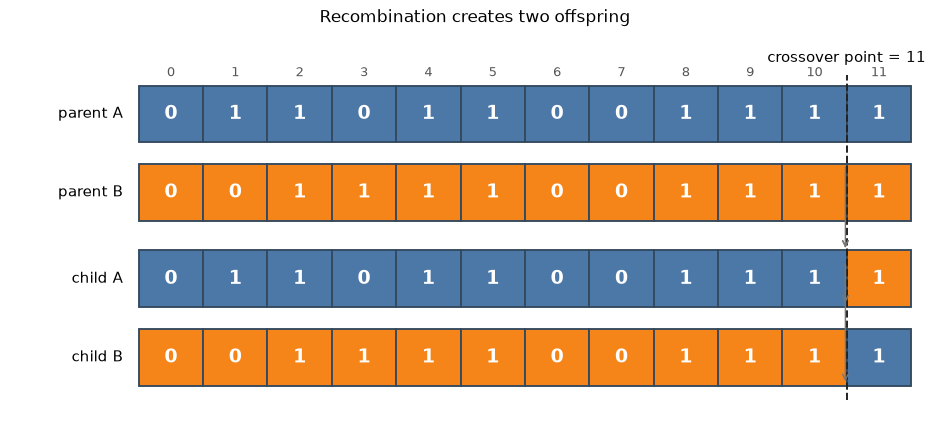

In [17]:
child_a, child_b, generation_cut = reference_one_point_crossover(
    parent_a, parent_b, generation_rng
)
plot_crossover(parent_a, parent_b, child_a, child_b, generation_cut,
               "Recombination creates two offspring")


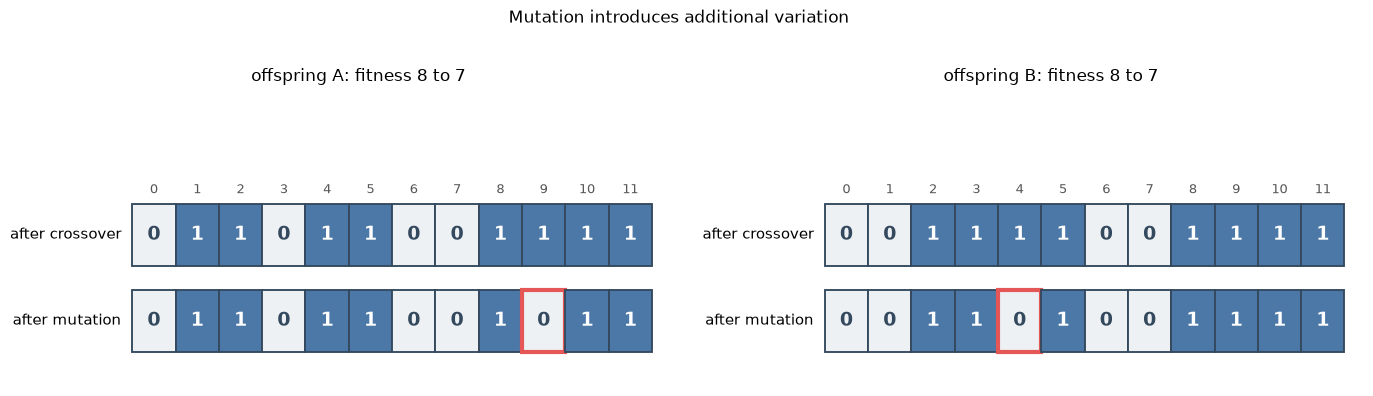

In [18]:
mutated_a, changes_a = reference_bit_flip_mutation(child_a, 0.12, generation_rng)
mutated_b, changes_b = reference_bit_flip_mutation(child_b, 0.12, generation_rng)

fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))
for ax, before, after, changed, label in [
    (axes[0], child_a, mutated_a, changes_a, "offspring A"),
    (axes[1], child_b, mutated_b, changes_b, "offspring B"),
]:
    plot_chromosome(ax, before, y=1.0, label="after crossover")
    plot_chromosome(ax, after, y=0.0, label="after mutation", highlights=changed, show_indices=False)
    format_chromosome_axis(ax, len(before), rows=2)
    ax.set_title(f"{label}: fitness {onemax(before)} to {onemax(after)}")
fig.suptitle("Mutation introduces additional variation", y=1.03)
plt.tight_layout()
plt.show()


elite survivor fitness: 8
offspring fitness: [7, 7]
next population shape: (8, 12)


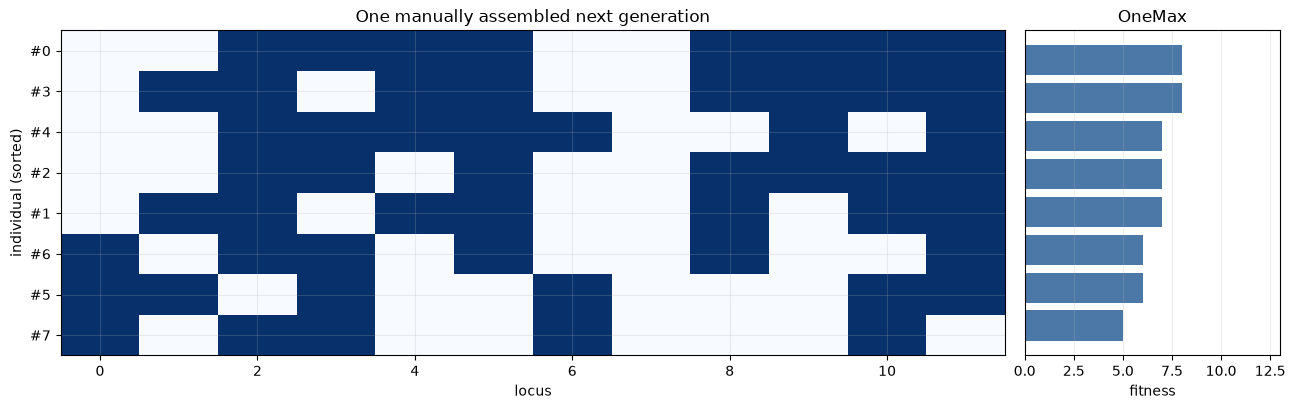

array([0, 3, 4, 2, 1, 6, 5, 7])

In [19]:
offspring = np.vstack([mutated_a, mutated_b])
offspring_fitness = evaluate_population(offspring)
elite_index = int(np.argmax(small_fitness))
elite = small_population[elite_index]

ranked_indices = np.argsort(small_fitness)[::-1]
remaining_indices = [index for index in ranked_indices if index != elite_index]
remaining = small_population[remaining_indices[:len(small_population) - len(offspring) - 1]]
next_population_manual = np.vstack([elite, offspring, remaining])
print("elite survivor fitness:", onemax(elite))
print("offspring fitness:", offspring_fitness.tolist())
print("next population shape:", next_population_manual.shape)
plot_population(next_population_manual, title="One manually assembled next generation")


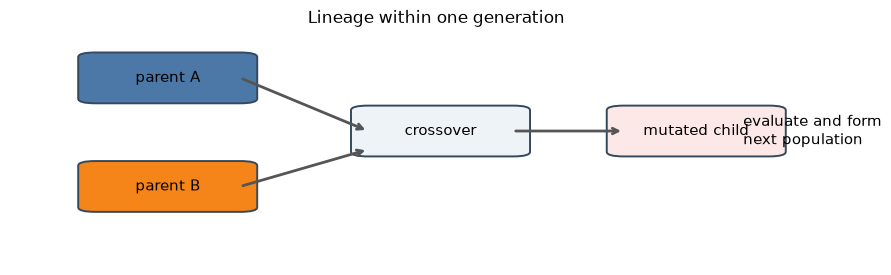

In [20]:
fig, ax = plt.subplots(figsize=(11, 3.0))
ax.axis("off")
boxes = [
    ("parent A", 0.10, 0.72, BLUE),
    ("parent B", 0.10, 0.25, ORANGE),
    ("crossover", 0.42, 0.49, "#eef3f7"),
    ("mutated child", 0.72, 0.49, "#fce8e6"),
]
for text, x, y, color in boxes:
    ax.add_patch(FancyBboxPatch((x, y), 0.17, 0.18, boxstyle="round,pad=0.02",
                                facecolor=color, edgecolor=DARK, lw=1.4))
    ax.text(x + 0.085, y + 0.09, text, ha="center", va="center", fontsize=11)
for start, end in [((0.27, 0.81), (0.42, 0.58)), ((0.27, 0.34), (0.42, 0.50)),
                   ((0.59, 0.58), (0.72, 0.58))]:
    ax.annotate("", xy=end, xytext=start,
                arrowprops={"arrowstyle": "->", "lw": 2, "color": "#555555"})
ax.text(0.86, 0.58, "evaluate and form\nnext population", va="center", fontsize=11)
ax.set_title("Lineage within one generation", pad=8)
plt.show()


## Exercise 4 - Predict Mutation-Rate Effects

For a population that already contains many high-fitness genotypes, predict
what may happen with very low, moderate, and high mutation rates. Consider
both fitness and diversity before revealing the answer.


### Encoded answer - Exercise 4


In [21]:
from base64 import b64decode

print(b64decode("VmVyeSBsb3cgbXV0YXRpb24gbWF5IHByZXNlcnZlIHN0cm9uZyBzdHJ1Y3R1cmVzIGJ1dCBjYW4gbGVhdmUgdG9vIGxpdHRsZSBuZXcKdmFyaWF0aW9uLiBBIG1vZGVyYXRlIHJhdGUgY2FuIGludHJvZHVjZSB1c2VmdWwgYWx0ZXJuYXRpdmVzIHdoaWxlIHJldGFpbmluZwptdWNoIG9mIHRoZSBwYXJlbnQgc3RydWN0dXJlLiBBIGhpZ2ggcmF0ZSBjYW4gaW5jcmVhc2UgZGl2ZXJzaXR5IGJ1dCBtYXkKcmVwZWF0ZWRseSBkaXNydXB0IGdvb2Qgc3RydWN0dXJlcy4gVGhlcmUgaXMgbm8gdW5pdmVyc2FsIGJlc3QgcmF0ZTogdGhlIHVzZWZ1bApzZXR0aW5nIGRlcGVuZHMgb24gcmVwcmVzZW50YXRpb24sIGZpdG5lc3MgbGFuZHNjYXBlLCBzZWxlY3Rpb24sIGFuZCBydW4gYnVkZ2V0Lg==").decode("utf-8"))


Very low mutation may preserve strong structures but can leave too little new
variation. A moderate rate can introduce useful alternatives while retaining
much of the parent structure. A high rate can increase diversity but may
repeatedly disrupt good structures. There is no universal best rate: the useful
setting depends on representation, fitness landscape, selection, and run budget.


## 8. A Complete Binary EA Loop

The reusable loop below uses tournament parent selection, one-point crossover,
bit-flip mutation, and simple elitism. Elitism keeps the current best individual
while the rest of the next generation is filled with offspring. This makes the
survivor-creation rule explicit and keeps the implementation compact.


In [22]:
def run_binary_ea(genome_length=32, population_size=30, generations=60,
                  mutation_rate=0.03, seed=0, tournament_size=3):
    rng = np.random.default_rng(seed)
    population = rng.integers(0, 2, size=(population_size, genome_length))
    history = {
        "best": [],
        "mean": [],
        "diversity": [],
        "populations": [],
    }

    for generation in range(generations + 1):
        fitness = evaluate_population(population)
        history["best"].append(float(fitness.max()))
        history["mean"].append(float(fitness.mean()))
        history["diversity"].append(population_diversity(population))
        history["populations"].append(population.copy())

        if generation == generations or fitness.max() == genome_length:
            break

        elite = population[np.argmax(fitness)].copy()
        offspring = []
        while len(offspring) < population_size - 1:
            parent_a, _, _ = tournament_select(population, fitness, rng, tournament_size)
            parent_b, _, _ = tournament_select(population, fitness, rng, tournament_size)
            child_a, child_b, _ = reference_one_point_crossover(parent_a, parent_b, rng)
            child_a, _ = reference_bit_flip_mutation(child_a, mutation_rate, rng)
            child_b, _ = reference_bit_flip_mutation(child_b, mutation_rate, rng)
            offspring.extend([child_a, child_b])

        population = np.vstack([elite, np.asarray(offspring[:population_size - 1])])

    return population, {key: np.asarray(value) for key, value in history.items()}

final_population, history = run_binary_ea(seed=12)
print("generations recorded:", len(history["best"]) - 1)
print("final best fitness:", int(history["best"][-1]))
print("final mean fitness:", round(history["mean"][-1], 2))


generations recorded: 13
final best fitness: 32
final mean fitness: 28.77


## Exercise 5 - Complete a Missing EA Step

Complete the survivor-creation line. The intended rule keeps the best current
individual and fills the remaining places with offspring.


In [23]:
def make_next_population_task(population, fitness, offspring):
    elite = population[np.argmax(fitness)].copy()
    # TODO: combine the elite and exactly len(population) - 1 offspring.
    next_population = None
    return next_population


### Encoded answer - Exercise 5


In [24]:
from base64 import b64decode

print(b64decode("ZGVmIG1ha2VfbmV4dF9wb3B1bGF0aW9uX3Rhc2socG9wdWxhdGlvbiwgZml0bmVzcywgb2Zmc3ByaW5nKToKICAgIGVsaXRlID0gcG9wdWxhdGlvbltucC5hcmdtYXgoZml0bmVzcyldLmNvcHkoKQogICAgbmV4dF9wb3B1bGF0aW9uID0gbnAudnN0YWNrKFtlbGl0ZSwgbnAuYXNhcnJheShvZmZzcHJpbmdbOmxlbihwb3B1bGF0aW9uKSAtIDFdKV0pCiAgICByZXR1cm4gbmV4dF9wb3B1bGF0aW9uCgpUaGlzIGlzIGEgc2ltcGxlIGdlbmVyYXRpb25hbCBzdXJ2aXZvciBydWxlIHdpdGggb25lIGVsaXRlIHN1cnZpdm9yLiBPdGhlcgpzdXJ2aXZvci1zZWxlY3Rpb24gc3RyYXRlZ2llcyBhcmUgcG9zc2libGUgYW5kIGNhbiBjaGFuZ2UgYWxnb3JpdGhtIGJlaGF2aW9yLg==").decode("utf-8"))


def make_next_population_task(population, fitness, offspring):
    elite = population[np.argmax(fitness)].copy()
    next_population = np.vstack([elite, np.asarray(offspring[:len(population) - 1])])
    return next_population

This is a simple generational survivor rule with one elite survivor. Other
survivor-selection strategies are possible and can change algorithm behavior.


## 9. Evolution Over Time

Best fitness shows the strongest candidate in each generation. Mean fitness
shows the population-wide trend. Diversity summarizes how mixed the allele
frequencies remain across loci. Population snapshots reveal convergence more
directly than a single final score.


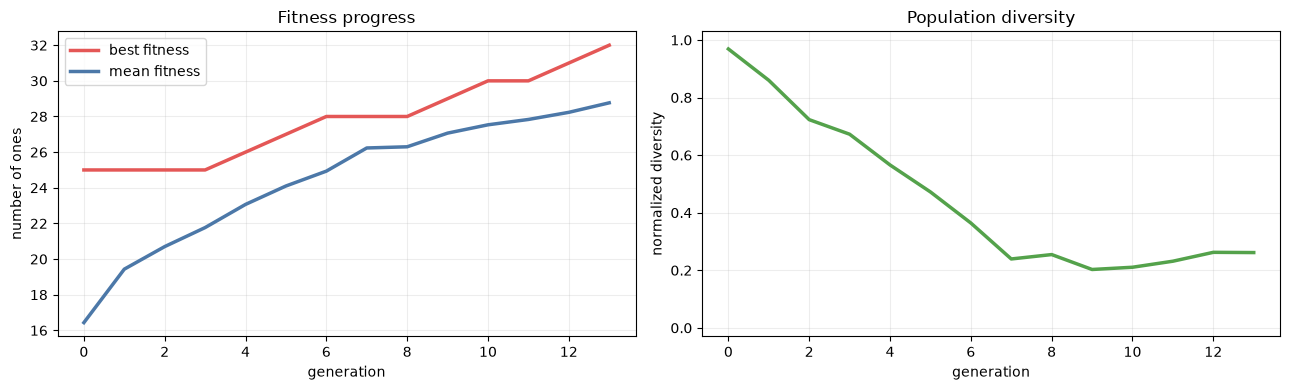

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
generations = np.arange(len(history["best"]))
axes[0].plot(generations, history["best"], color=RED, lw=2.5, label="best fitness")
axes[0].plot(generations, history["mean"], color=BLUE, lw=2.5, label="mean fitness")
axes[0].set(xlabel="generation", ylabel="number of ones", title="Fitness progress")
axes[0].legend()
axes[1].plot(generations, history["diversity"], color="#54a24b", lw=2.5)
axes[1].set(xlabel="generation", ylabel="normalized diversity", ylim=(-0.03, 1.03),
            title="Population diversity")
plt.tight_layout()
plt.show()


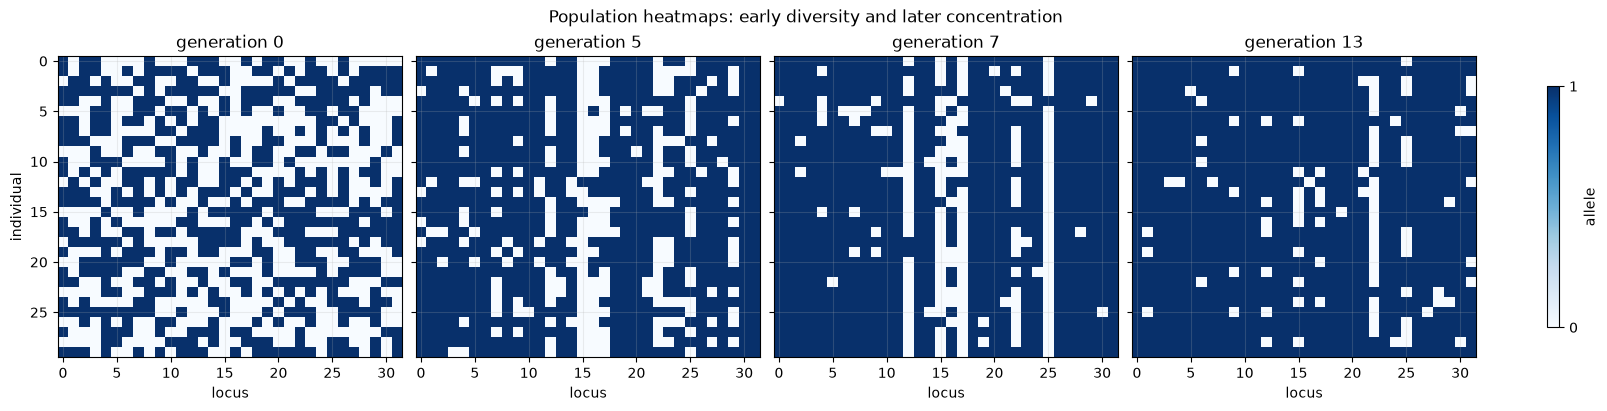

In [26]:
snapshot_indices = sorted(set([0, min(5, len(history["populations"]) - 1),
                               len(history["populations"]) // 2,
                               len(history["populations"]) - 1]))
fig, axes = plt.subplots(1, len(snapshot_indices), figsize=(16, 4), sharey=True,
                         constrained_layout=True)
if len(snapshot_indices) == 1:
    axes = [axes]
for ax, index in zip(axes, snapshot_indices):
    image = ax.imshow(history["populations"][index], aspect="auto", cmap=plt.cm.Blues, vmin=0, vmax=1)
    ax.set(title=f"generation {index}", xlabel="locus")
axes[0].set_ylabel("individual")
fig.colorbar(image, ax=axes, shrink=0.8, ticks=[0, 1], label="allele")
fig.suptitle("Population heatmaps: early diversity and later concentration")
plt.show()


## Exercise 6 - Interpret the Curves

Interpret the fitness and diversity curves. Why can diversity decline while
mean fitness rises? Why would a diversity value near zero be useful and
concerning at the same time?


### Encoded answer - Exercise 6


In [27]:
from base64 import b64decode

print(b64decode("U2VsZWN0aW9uIGFuZCBlbGl0aXNtIGZhdm9yIGhpZ2gtZml0bmVzcyBnZW5vdHlwZXMsIHNvIG1lYW4gZml0bmVzcyBjYW4gcmlzZSBhcwp0aGUgcG9wdWxhdGlvbiBiZWNvbWVzIG1vcmUgc2ltaWxhci4gTmVhci16ZXJvIGRpdmVyc2l0eSBjYW4gbWVhbiB0aGUKcG9wdWxhdGlvbiBoYXMgY29udmVyZ2VkIG9uIGEgc3Ryb25nIHNvbHV0aW9uLiBJdCBjYW4gYWxzbyBiZSBjb25jZXJuaW5nIGJlY2F1c2UKZmV3IGFsdGVybmF0aXZlcyByZW1haW4sIG1ha2luZyBmdXJ0aGVyIGV4cGxvcmF0aW9uIGRpZmZpY3VsdCBpZiB0aGF0IHNvbHV0aW9uCmlzIG5vdCBnbG9iYWxseSBiZXN0Lg==").decode("utf-8"))


Selection and elitism favor high-fitness genotypes, so mean fitness can rise as
the population becomes more similar. Near-zero diversity can mean the
population has converged on a strong solution. It can also be concerning because
few alternatives remain, making further exploration difficult if that solution
is not globally best.


## 10. Mutation Rate and Exploration-Exploitation

The next experiment keeps every setting fixed except mutation rate. The curves
should be interpreted as one set of stochastic runs, not a universal ranking of
parameter values.


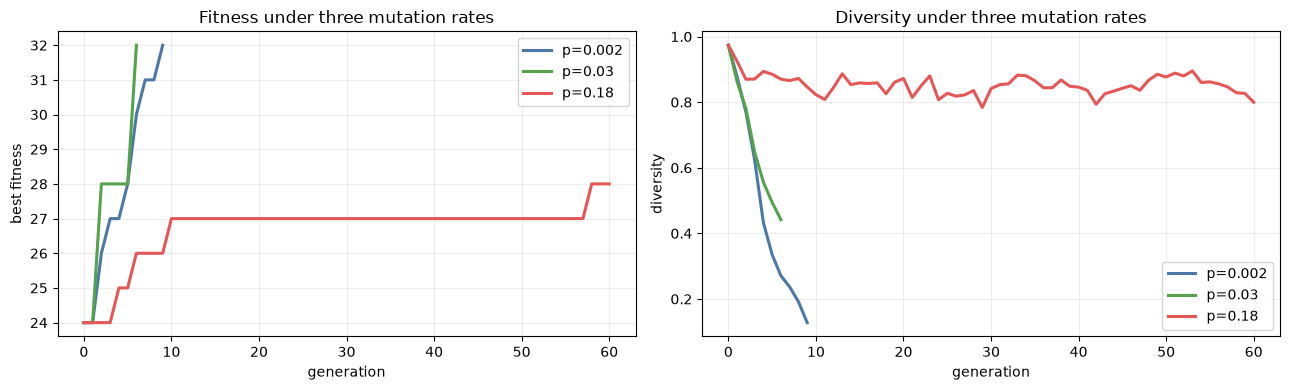

In [28]:
experiment_rates = [0.002, 0.03, 0.18]
colors = [BLUE, "#54a24b", RED]
histories = {}
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for rate, color in zip(experiment_rates, colors):
    _, rate_history = run_binary_ea(mutation_rate=rate, seed=18, generations=60)
    histories[rate] = rate_history
    axes[0].plot(rate_history["best"], color=color, lw=2.2, label=f"p={rate}")
    axes[1].plot(rate_history["diversity"], color=color, lw=2.2, label=f"p={rate}")
axes[0].set(xlabel="generation", ylabel="best fitness", title="Fitness under three mutation rates")
axes[1].set(xlabel="generation", ylabel="diversity", title="Diversity under three mutation rates")
axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()


## 11. Stochasticity

Random initialization, tournaments, cut points, and mutations make repeated
EA runs different. This short experiment runs the same configuration under
several seeds and compares both the observed fitness trajectories and the
generation at which the optimum is first reached.


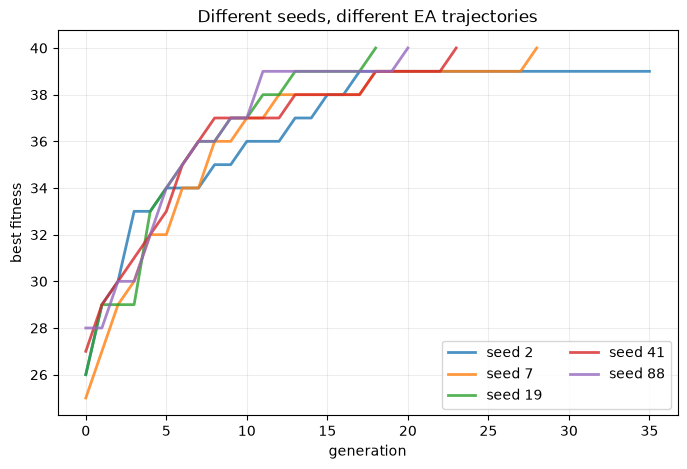

final best fitness values: [39, 40, 40, 40, 40]
generations to reach the optimum (None means not reached): [None, 28, 18, 23, 20]
mean final best fitness: 39.8


In [29]:
seeds = [2, 7, 19, 41, 88]
target_fitness = 40
fig, ax = plt.subplots()
final_scores = []
arrivals = []
for seed in seeds:
    _, seed_history = run_binary_ea(genome_length=target_fitness, population_size=30,
                                    seed=seed, generations=35, mutation_rate=0.03)
    ax.plot(seed_history["best"], lw=2, alpha=0.8, label=f"seed {seed}")
    final_scores.append(seed_history["best"][-1])
    first_target = next((generation for generation, score in enumerate(seed_history["best"])
                         if score == target_fitness), None)
    arrivals.append(first_target)
ax.set(xlabel="generation", ylabel="best fitness", title="Different seeds, different EA trajectories")
ax.legend(ncol=2)
plt.show()
print("final best fitness values:", [int(score) for score in final_scores])
print("generations to reach the optimum (None means not reached):", arrivals)
print("mean final best fitness:", round(float(np.mean(final_scores)), 2))


# Part 2 - Transfer Across Representations

Changing representation changes what a valid candidate is and therefore changes
which variation operators make sense. This section remains conceptual except
for one small independent real-valued illustration.


## 12. Representation Categories

| Representation | Example meaning | Main design question |
|---|---|---|
| Binary | on/off choices | how should bits change and combine? |
| Integer | discrete values | what changes remain within bounds? |
| Real-valued | numerical parameters | how large should perturbations be? |
| Ordering | a sequence of distinct elements | how can validity and structure be preserved? |
| Tree | expressions | how should structural changes work? |


## 13. A Small Real-Valued Example

With real-valued parameters, Gaussian mutation can add a small random vector,
and arithmetic recombination can create a point between two parents. This is an
illustration of representation-dependent operator design, not a second complete
optimizer.


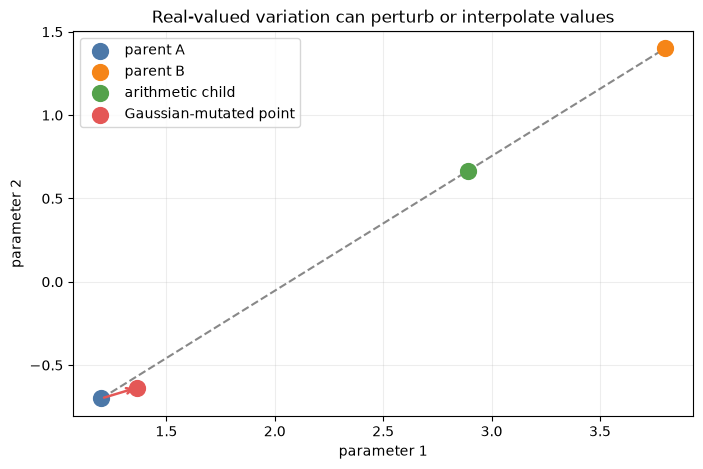

In [30]:
real_parent_a = np.array([1.2, -0.7])
real_parent_b = np.array([3.8, 1.4])
alpha = 0.35
arithmetic_child = alpha * real_parent_a + (1 - alpha) * real_parent_b
sigma = 0.3
real_rng = np.random.default_rng(23)
gaussian_noise = real_rng.normal(0.0, sigma, size=real_parent_a.shape)
mutated_real = real_parent_a + gaussian_noise

fig, ax = plt.subplots()
ax.scatter(*real_parent_a, s=130, color=BLUE, label="parent A", zorder=3)
ax.scatter(*real_parent_b, s=130, color=ORANGE, label="parent B", zorder=3)
ax.scatter(*arithmetic_child, s=130, color="#54a24b", label="arithmetic child", zorder=3)
ax.scatter(*mutated_real, s=130, color=RED, label="Gaussian-mutated point", zorder=3)
ax.plot([real_parent_a[0], real_parent_b[0]], [real_parent_a[1], real_parent_b[1]],
        color="#888888", ls="--")
ax.annotate("", xy=mutated_real, xytext=real_parent_a,
            arrowprops={"arrowstyle": "->", "color": RED, "lw": 1.8})
ax.set(xlabel="parameter 1", ylabel="parameter 2",
       title="Real-valued variation can perturb or interpolate values")
ax.legend()
plt.show()


## Exercise 7 - Representation Changes the Design

Explain why a bit-flip operation is natural for binary data but not
automatically meaningful for a real-valued parameter vector or a sequence of
distinct symbols.


### Encoded answer - Exercise 7


In [31]:
from base64 import b64decode

print(b64decode("QSBiaXQgZmxpcCByZWxpZXMgb24gdGhlIGJpbmFyeSBhbGxlbGUgc2V0IHswLCAxfS4gQSByZWFsLXZhbHVlZCBwYXJhbWV0ZXIgaGFzCmEgZGlmZmVyZW50IGdlb21ldHJ5LCBzbyBhIG51bWVyaWNhbCBwZXJ0dXJiYXRpb24gb3IgaW50ZXJwb2xhdGlvbiBjYW4gYmUgbW9yZQptZWFuaW5nZnVsLiBBIHNlcXVlbmNlIG9mIGRpc3RpbmN0IHN5bWJvbHMgaGFzIHZhbGlkaXR5IGNvbnN0cmFpbnRzLCBzbyBibGluZGx5CnJlcGxhY2luZyBvbmUgdmFsdWUgbWF5IGNyZWF0ZSBkdXBsaWNhdGVzIGFuZCBvbWl0IGFub3RoZXIgcmVxdWlyZWQgc3ltYm9sLgpSZXByZXNlbnRhdGlvbiBkZXRlcm1pbmVzIGJvdGggd2hhdCB2YXJpYXRpb24gbWVhbnMgYW5kIHdoYXQgaXQgbXVzdCBwcmVzZXJ2ZS4=").decode("utf-8"))


A bit flip relies on the binary allele set {0, 1}. A real-valued parameter has
a different geometry, so a numerical perturbation or interpolation can be more
meaningful. A sequence of distinct symbols has validity constraints, so blindly
replacing one value may create duplicates and omit another required symbol.
Representation determines both what variation means and what it must preserve.


## 14. Ordering: A Validity Discussion

Consider two orderings of the same five symbols:

$$
[A,B,C,D,E]
\qquad
[E,D,C,B,A].
$$

A naive binary-style tail exchange could produce:

$$
[A,B,C,B,A].
$$

What is wrong with this result? Which properties must a representation-aware
operator preserve? Position, relative order, and adjacency are distinct kinds
of structure. Specialized variation operators exist for such representations.


## Exercise 8 - Explain the Invalid Ordering

State why the displayed child is invalid. Do not propose or implement a repair
procedure.


### Encoded answer - Exercise 8


In [32]:
from base64 import b64decode

print(b64decode("VGhlIGNoaWxkIHJlcGVhdHMgQSBhbmQgQiwgd2hpbGUgRCBhbmQgRSBhcmUgbWlzc2luZy4gSXQgaXMgbm90IGFuIG9yZGVyaW5nIG9mCnRoZSBvcmlnaW5hbCBmaXZlIGRpc3RpbmN0IHN5bWJvbHMuIEEgdmFsaWQgb3BlcmF0b3IgbXVzdCByZXNwZWN0IHRoZQpyZXByZXNlbnRhdGlvbiBjb25zdHJhaW50IHRoYXQgZWFjaCByZXF1aXJlZCBlbGVtZW50IG9jY3VycyBleGFjdGx5IG9uY2Uu").decode("utf-8"))


The child repeats A and B, while D and E are missing. It is not an ordering of
the original five distinct symbols. A valid operator must respect the
representation constraint that each required element occurs exactly once.


## 15. Tree Representation

Tree-shaped genotypes can represent expressions:

$$
\begin{array}{c}
\quad +\\
/ \quad \backslash\\
x \quad *\\
\quad / \quad \backslash\\
\quad 2 \quad y
\end{array}
$$

A tree can change in depth and width, so its variation must be structural. The
central transfer principle remains: choose a representation, identify its
constraints and useful structure, then design valid evaluation and variation.


## Practice Summary

The binary OneMax example exposed the whole EA cycle: initialize a population,
evaluate fitness, select parents, recombine, mutate, create survivors, and
repeat. Evolutionary behavior is shaped by stochasticity, diversity, selection
pressure, and variation rates. The same cycle transfers across representations,
but the representation determines what valid variation can be.
